# Imports

In [13]:
# PyTorch
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as nnFunc
import torch.amp as amp
# General
import numpy as np
import matplotlib.pyplot as plt
# Optimizer
import torch.optim as optim
# pretty print
from pprint import pprint

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 13.0


## Dataset

This code uses the CIFAR-10 dataset.
(https://www.cs.toronto.edu/~kriz/cifar.html)

## 1. Transform setting
The original images are in PIL (0 to 255 for each pixel). First we convert it to a tensor format (0 to 1). Then to make the data to be zero centering, we make the range to be between -1 to 1. If we use the following equation for each data, we can make it zero centered:
\begin{equation}
  output = \frac{input - mean}{std}
\end{equation}
This is being done by setting the `mean` and `standard deviation` to be 0.5.

In [14]:
transform = transforms.Compose([  transforms.RandomHorizontalFlip(),
                                transforms.RandomCrop(32, padding=4),
                                transforms.ToTensor(),
                                transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                                ])

## 2. Making the training set
Now we load the actual dataset and make the training dataset.
1. Load CIFAR10 dataset (Download and prepare dataset)
    1. Put it in `./data` directory.
    2. Download it
    3. Do the specified transformation on the dataset
2. Create the data loader (pipelining settings)
    1. Brake it to batches with size of 32
    2. Shuffle the deck in every epoch
    3. Use 4 number of workers to make the training faster


In [15]:
batchSize = 512
numberOfWorkers = 0

trainSet = torchvision.datasets.CIFAR10(root='./data_CIFAR10',
                                        train=True,
                                        download=True,
                                        transform = transform)

trainLoader = torch.utils.data.DataLoader(trainSet,
                                          batch_size=batchSize,
                                          shuffle=True,
                                          num_workers=numberOfWorkers,
                                          pin_memory=True,
                                          persistent_workers=False)

## 3. Making the test set
Now making the test set. The procedure is the same as making the training set with some minor modifications.

In [16]:
testSet = torchvision.datasets.CIFAR10(root='./data_CIFAR10',
                                       train=False,
                                       download=True,
                                       transform=transform)

testLoader = torch.utils.data.DataLoader(testSet,
                                         batch_size=batchSize,
                                         shuffle=False,
                                         num_workers=numberOfWorkers,
                                         pin_memory=True,
                                         persistent_workers=False) # Updated here too
viz_batchSize = 4
vizLoader = torch.utils.data.DataLoader(testSet, batch_size=viz_batchSize, shuffle=True)

## 4. The classes

In [17]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
pprint(classes)

('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## DEUBG1
Showing some of the images from the dataset.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].


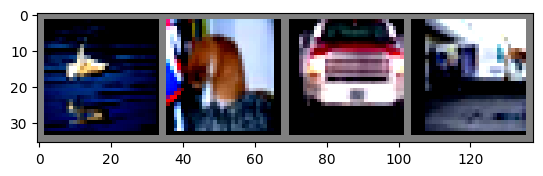

'bird  cat   truck truck'


In [18]:
# functions to show an image
def imshow(img):
  img = img / 2 + 0.5 # unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()
# get some random training images
dataiter = iter(vizLoader)
images, labels = next(dataiter)
# show images
imshow(torchvision.utils.make_grid(images))
# print labels
pprint(' '.join(f'{classes[labels[j]]:5s}' for j in range(viz_batchSize)))

## 5. Defining the CNN model

In [19]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 6, 5) 
    self.pool1 = nn.AvgPool2d(2, 2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.pool2 = nn.AvgPool2d(2, 2)
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool1(torch.tanh(self.conv1(x)))
    x = self.pool2(torch.tanh(self.conv2(x)))
    
    x = x.view(-1, 16 * 5 * 5)
    
    x = nnFunc.relu(self.fc1(x))
    x = nnFunc.relu(self.fc2(x))
    x = self.fc3(x)
    
    return x

## 6. Instansiating the CNN model

In [20]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
net = Net()
net.apply(init_weights)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## 7. Move the model to GPU

In [21]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [22]:
net.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## 8. Degine loss function and optimizer

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=10)

## 9. Traing the network

In [24]:
scaler = amp.GradScaler('cuda')

epochs = 100
printFrequency = len(trainLoader) // 4

for epoch in range(epochs):
    net.train() # Ensure model is in training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    # --- TRAINING PHASE ---
    for i, data in enumerate(trainLoader, 0):
        inputs, labels = data[0].to(device, non_blocking=True), data[1].to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with amp.autocast('cuda'):
            outputs = net(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item()
        
        if i % printFrequency == (printFrequency - 1):
            accuracy = 100 * correct / total
            print(f'Epoch {epoch + 1} | Batch {i + 1}/{len(trainLoader)} | loss: {running_loss / printFrequency:.3f} | acc: {accuracy:.2f}%')
            running_loss, correct, total = 0.0, 0, 0

    # --- VALIDATION PHASE ---
    net.eval() 
    val_correct = 0
    val_total = 0
    with torch.no_grad(): # No gradients needed for validation
        for data in testLoader:
            images, labels = data[0].to(device), data[1].to(device)
            with amp.autocast('cuda'):
                outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']
    print(f'>> Epoch {epoch + 1} SUMMARY: Val Acc: {val_acc:.2f}% | Current LR: {current_lr}')
    
    # --- AUTOMATIC LR DROP ---
    scheduler.step(val_acc)

print('Finished Training')

Epoch 1 | Batch 24/98 | loss: 3.063 | acc: 14.67%
Epoch 1 | Batch 48/98 | loss: 2.075 | acc: 25.06%
Epoch 1 | Batch 72/98 | loss: 1.974 | acc: 28.53%
Epoch 1 | Batch 96/98 | loss: 1.910 | acc: 30.32%
>> Epoch 1 SUMMARY: Val Acc: 32.30% | Current LR: 0.1
Epoch 2 | Batch 24/98 | loss: 1.851 | acc: 31.93%
Epoch 2 | Batch 48/98 | loss: 1.820 | acc: 33.81%
Epoch 2 | Batch 72/98 | loss: 1.751 | acc: 36.30%
Epoch 2 | Batch 96/98 | loss: 1.737 | acc: 36.17%
>> Epoch 2 SUMMARY: Val Acc: 37.54% | Current LR: 0.1
Epoch 3 | Batch 24/98 | loss: 1.689 | acc: 38.19%
Epoch 3 | Batch 48/98 | loss: 1.642 | acc: 39.54%
Epoch 3 | Batch 72/98 | loss: 1.664 | acc: 39.36%
Epoch 3 | Batch 96/98 | loss: 1.612 | acc: 41.13%
>> Epoch 3 SUMMARY: Val Acc: 41.57% | Current LR: 0.1
Epoch 4 | Batch 24/98 | loss: 1.598 | acc: 41.54%
Epoch 4 | Batch 48/98 | loss: 1.575 | acc: 42.54%
Epoch 4 | Batch 72/98 | loss: 1.545 | acc: 43.45%
Epoch 4 | Batch 96/98 | loss: 1.533 | acc: 44.03%
>> Epoch 4 SUMMARY: Val Acc: 44.83% | 

## 10. Test the network on the test data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].


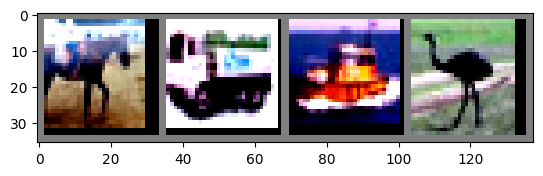

GroundTruth:  horse truck ship  bird 


In [25]:
dataIter = iter(vizLoader)
images, labels = next(dataIter)
# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(viz_batchSize)))

In [26]:
images, labels = images.to(device), labels.to(device)

outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j].item()]:5s}' for j in range(len(predicted))))

Predicted:  horse truck ship  bird 


## 11. Test the network on the whole dataset

In [27]:
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for data in testLoader:
        images, labels = data[0].to(device), data[1].to(device)
        
        outputs = net(images)
        
        # 1. Calculate the loss for this batch
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        # 2. Calculate accuracy as before
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate the average loss over all batches
avg_test_loss = test_loss / len(testLoader)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Loss: 1.0545
Test Accuracy: 63.67%


## 12. Check performance within each class

In [28]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testLoader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 70.4 %
Accuracy for class: car   is 73.2 %
Accuracy for class: bird  is 43.0 %
Accuracy for class: cat   is 39.9 %
Accuracy for class: deer  is 53.3 %
Accuracy for class: dog   is 57.2 %
Accuracy for class: frog  is 73.7 %
Accuracy for class: horse is 69.4 %
Accuracy for class: ship  is 78.4 %
Accuracy for class: truck is 72.4 %
